In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/content/drive/MyDrive/dataset
/content/drive/MyDrive/dataset/train
/content/drive/MyDrive/dataset/train/Early_blight
/content/drive/MyDrive/dataset/train/Late_blight
/content/drive/MyDrive/dataset/train/healthy
/content/drive/MyDrive/dataset/valid
/content/drive/MyDrive/dataset/valid/Late_blight
/content/drive/MyDrive/dataset/valid/healthy
/content/drive/MyDrive/dataset/valid/Early_blight


In [ ]:
train_path = "/content/drive/MyDrive/dataset/train"
valid_path = "/content/drive/MyDrive/dataset/valid"



In [ ]:
train_gen = ImageDataGenerator(rescale=1./255)

valid_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_gen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8619 images belonging to 3 classes.
Found 2240 images belonging to 3 classes.


In [ ]:
print(train_data.class_indices)

{'Early_blight': 0, 'Late_blight': 1, 'healthy': 2}


In [ ]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(3,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 3674s 13s/step - accuracy: 0.6460 - loss: 0.7508 - val_accuracy: 0.8362 - val_loss: 0.4184
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 55s 203ms/step - accuracy: 0.8264 - loss: 0.4200 - val_accuracy: 0.8830 - val_loss: 0.3100
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 55s 204ms/step - accuracy: 0.8771 - loss: 0.3172 - val_accuracy: 0.8031 - val_loss: 0.4818
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 54s 202ms/step - accuracy: 0.8835 - loss: 0.2856 - val_accuracy: 0.9170 - val_loss: 0.2202
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 54s 198ms/step - accuracy: 0.9109 - loss: 0.2267 - val_accuracy: 0.9170 - val_loss: 0.2243
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 55s 205ms/step - accuracy: 0.9335 - loss: 0.1687 - val_accuracy: 0.9371 - val_loss: 0.1844
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 54s 202ms/step - accuracy: 0.9360 - loss: 0.1660 - val_accuracy: 0.9308 - val_loss: 0.1830
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 55s 203ms/step - accuracy: 0.9486 - loss: 0

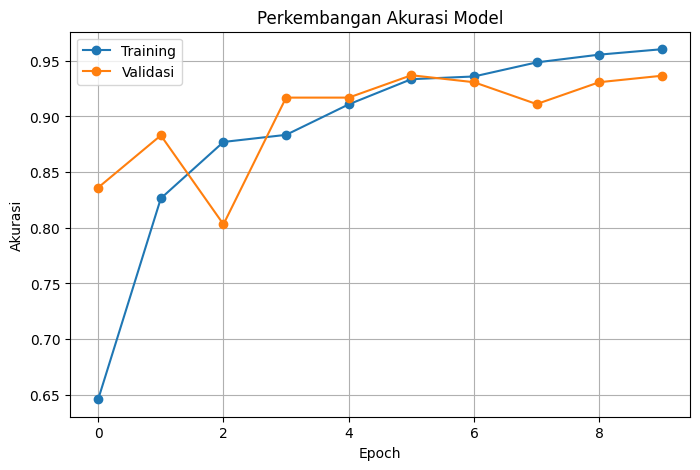

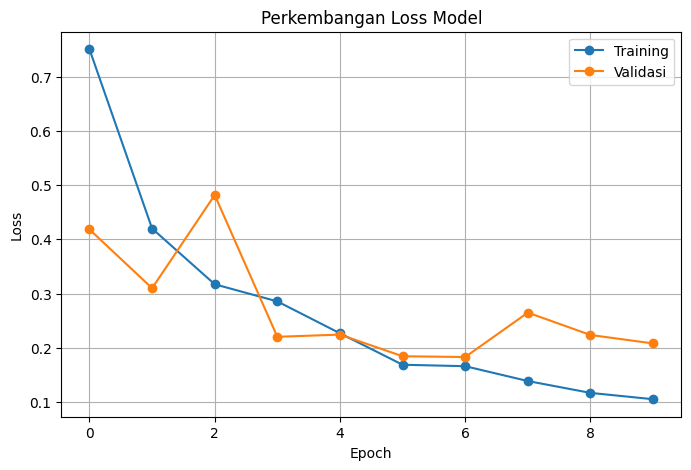

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o', label='Training')
plt.plot(history.history['val_accuracy'], marker='o', label='Validasi')

plt.title('Perkembangan Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o', label='Training')
plt.plot(history.history['val_loss'], marker='o', label='Validasi')

plt.title('Perkembangan Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

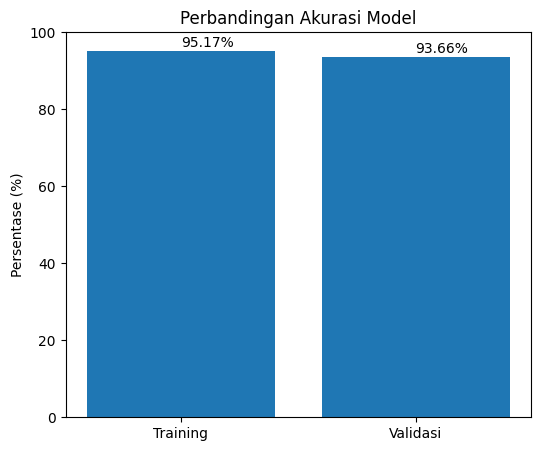

In [ ]:
import matplotlib.pyplot as plt

label = ['Training', 'Validasi']
nilai = [95.17, 93.66]

plt.figure(figsize=(6,5))
plt.bar(label, nilai)

plt.ylim(0,100)
plt.ylabel("Persentase (%)")
plt.title("Perbandingan Akurasi Model")

for i,v in enumerate(nilai):
    plt.text(i,v+1,f"{v:.2f}%")

plt.show()

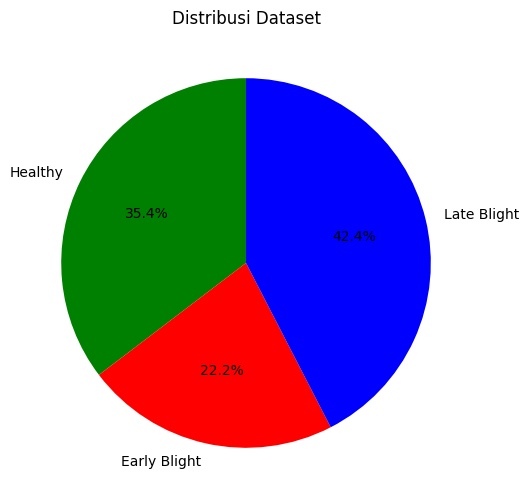

In [ ]:
labels = ['Healthy','Early Blight','Late Blight']
sizes = [1591,1000,1909]

plt.figure(figsize=(6,6))
plt.pie(sizes,
        labels=labels,
        colors=['green', 'red', 'blue'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribusi Dataset")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
valid_data.reset()

pred = cnn_model.predict(valid_data)

pred_class = np.argmax(pred, axis=1)

true_class = valid_data.classes

class_names = list(valid_data.class_indices.keys())

70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step


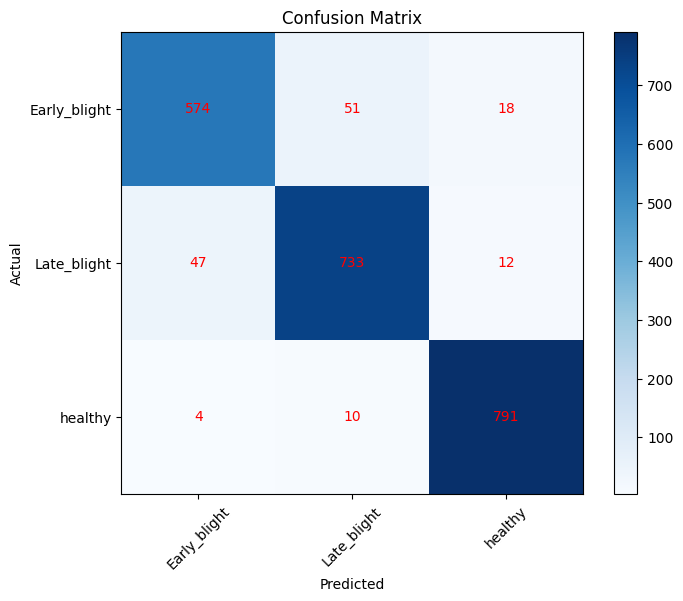

In [ ]:
cm = confusion_matrix(true_class, pred_class)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="red")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(
    true_class,
    pred_class,
    target_names=class_names
))

              precision    recall  f1-score   support

Early_blight       0.92      0.89      0.91       643
 Late_blight       0.92      0.93      0.92       792
     healthy       0.96      0.98      0.97       805

    accuracy                           0.94      2240
   macro avg       0.94      0.93      0.93      2240
weighted avg       0.94      0.94      0.94      2240



In [ ]:
cnn_model.save("tomato_leaf_disease_model.keras")

Saving fb5dc387-cb1d-49bb-b81e-58d60705a2fd___GHLB_PS Leaf 1.3 Day 16.jpg to fb5dc387-cb1d-49bb-b81e-58d60705a2fd___GHLB_PS Leaf 1.3 Day 16.jpg


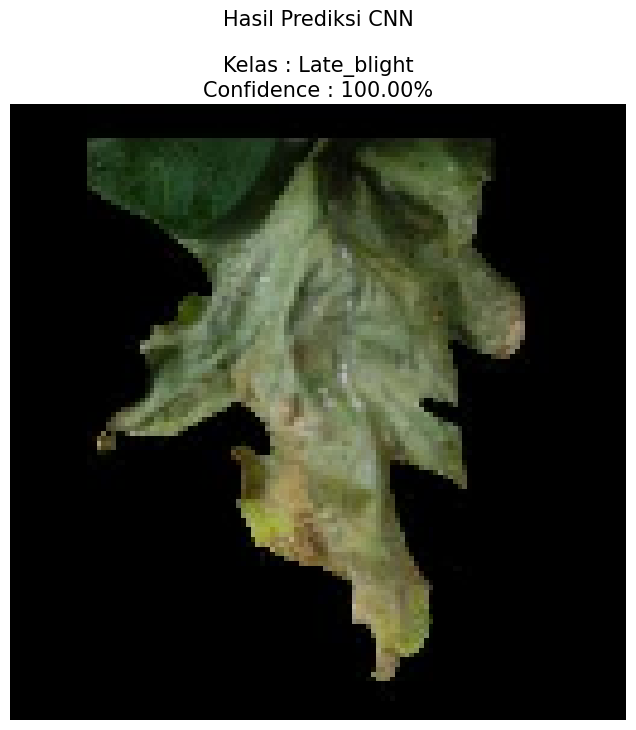

HASIL PREDIKSI CNN
Kelas      : Late_blight
Confidence : 100.00%


In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Upload gambar
uploaded = files.upload()

# Ambil nama file
img_path = list(uploaded.keys())[0]

# Load gambar
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = cnn_model.predict(img_array, verbose=0)

# Nama kelas
class_names = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

# Tampilkan gambar
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Hasil Prediksi CNN\n\n"
    f"Kelas : {predicted_class}\n"
    f"Confidence : {confidence:.2f}%",
    fontsize=15
)

plt.show()

print("="*40)
print("HASIL PREDIKSI CNN")
print("="*40)
print("Kelas      :", predicted_class)
print("Confidence :", f"{confidence:.2f}%")